# Regression Models for RUL Prediction
This notebook implements classical regression algorithms for predicting Remaining Useful Life (RUL).


In [10]:
# Load dataset

In [11]:
import pandas as pd

cycle_df = pd.read_csv("processed_cycle_data.csv")

print("Dataset Shape:", cycle_df.shape)
cycle_df.head()

Dataset Shape: (30, 8)


,cycle,Current,Temperature,Vbat1,Vbat2,Vbat3,Vbat4,RUL
0,1,0.452864,24.290877,3.653491,3.643456,3.644663,3.660899,29
1,2,0.451678,24.472032,3.672443,3.668271,3.663137,3.674473,28
2,3,0.949160,25.802454,3.624014,3.620399,3.601973,3.621333,27
3,4,0.952717,25.803744,3.640035,3.646614,3.631315,3.643079,26
4,5,0.937457,25.425552,3.635326,3.634732,3.634096,3.638728,25


In [12]:
X = cycle_df.drop(columns=["RUL", "cycle"])
y = cycle_df["RUL"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (30, 6)
Target Shape: (30,)


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

🔹 Linear Regression Performance
RMSE: 2.635348839029089
MAE: 2.1670946388497034
R² : 0.9072961490094954


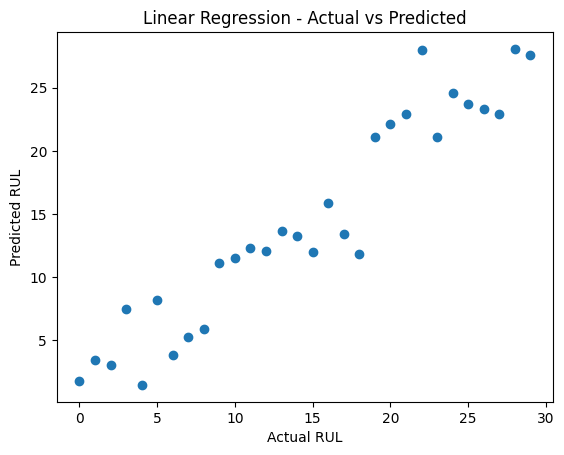

In [14]:
from sklearn.linear_model import LinearRegression

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

y_pred_lr = cross_val_predict(pipeline_lr, X, y, cv=kf)

mse_lr = mean_squared_error(y, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y, y_pred_lr)
r2_lr = r2_score(y, y_pred_lr)

print("🔹 Linear Regression Performance")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R² :", r2_lr)

plt.figure()
plt.scatter(y, y_pred_lr)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

In [15]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 2, 3]
best_r2 = -999
best_degree = None

for d in degrees:
    pipeline_poly = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d)),
        ("model", LinearRegression())
    ])
    
    y_pred_poly = cross_val_predict(pipeline_poly, X, y, cv=kf)
    r2 = r2_score(y, y_pred_poly)
    
    print(f"Degree {d} R²: {r2}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_degree = d

print("Best Degree:", best_degree)

Degree 1 R²: 0.9072961490094953
Degree 2 R²: -3.3893122013826904
Degree 3 R²: -2.3755559263760593
Best Degree: 1


In [16]:
from sklearn.linear_model import Ridge

pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid_ridge = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=kf, scoring="r2")
grid_ridge.fit(X, y)

best_ridge = grid_ridge.best_estimator_
y_pred_ridge = cross_val_predict(best_ridge, X, y, cv=kf)

r2_ridge = r2_score(y, y_pred_ridge)

print("Best Alpha (Ridge):", grid_ridge.best_params_)
print("Ridge R²:", r2_ridge)

Best Alpha (Ridge): {'model__alpha': 0.1}
Ridge R²: 0.9131342497078134


In [17]:
from sklearn.linear_model import Lasso

pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])

param_grid_lasso = {"model__alpha": [0.001, 0.01, 0.1, 1, 10]}

grid_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=kf, scoring="r2")
grid_lasso.fit(X, y)

best_lasso = grid_lasso.best_estimator_
y_pred_lasso = cross_val_predict(best_lasso, X, y, cv=kf)

r2_lasso = r2_score(y, y_pred_lasso)

print("Best Alpha (Lasso):", grid_lasso.best_params_)
print("Lasso R²:", r2_lasso)

Best Alpha (Lasso): {'model__alpha': 0.1}
Lasso R²: 0.9188318959420657


In [18]:
from sklearn.linear_model import ElasticNet

pipeline_en = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000))
])

param_grid_en = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

grid_en = GridSearchCV(pipeline_en, param_grid_en, cv=kf, scoring="r2")
grid_en.fit(X, y)

best_en = grid_en.best_estimator_
y_pred_en = cross_val_predict(best_en, X, y, cv=kf)

r2_en = r2_score(y, y_pred_en)

print("Best Params (Elastic Net):", grid_en.best_params_)
print("Elastic Net R²:", r2_en)

Best Params (Elastic Net): {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
Elastic Net R²: 0.9155053641711821


In [19]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso", "Elastic Net"],
    "R² Score": [r2_lr, best_r2, r2_ridge, r2_lasso, r2_en]
})

comparison

,Model,R² Score
0,Linear,0.907296
1,Polynomial,0.907296
2,Ridge,0.913134
3,Lasso,0.918832
4,Elastic Net,0.915505
